In [110]:
# CELL 1: Imports and Setup
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import json
import mlflow
from datetime import datetime
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import ViTForImageClassification

# Configuration
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
pd.set_option('display.max_columns', None)
print(f"Using device: {DEVICE}")

Using device: mps


## Load models and artifactts

In [111]:
# CELL 2: Load Models and Artifacts
import json
import joblib
import torch
import torch.nn as nn
from transformers import ViTForImageClassification

# Load label encoder
label_encoder = joblib.load('../../../development/models/quality_assurance/embeddings/label_encoder.pkl')

# Load severity mapping
with open('../../../development/models/quality_assurance/embeddings/severity_mapping.json', 'r') as f:
    severity_mapping = json.load(f)

# Load class mapping
with open('../../../development/models/quality_assurance/database/class_mapping.json', 'r') as f:
    class_mapping = json.load(f)

# Initialize ViT architecture
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=len(label_encoder.classes_),
    ignore_mismatched_sizes=True
)

# Load checkpoint state dict
checkpoint_path = '../../../development/models/quality_assurance/models/vit_damage_classifier.pth'
state_dict = torch.load(checkpoint_path, map_location='cpu')

# Unwrap if dictionary contains nested keys
if isinstance(state_dict, dict):
    if "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    elif "model" in state_dict:
        state_dict = state_dict["model"]

# Remap state dict keys to fit the updated Hugging Face ViT structure
new_state_dict = {}
for key, value in state_dict.items():
    new_key = key.replace("vit.encoder.layer.", "vit.layers.")
    new_key = new_key.replace(".attention.attention.query.", ".attention.q_proj.")
    new_key = new_key.replace(".attention.attention.key.", ".attention.k_proj.")
    new_key = new_key.replace(".attention.attention.value.", ".attention.v_proj.")
    new_key = new_key.replace(".attention.output.dense.", ".attention.o_proj.")
    new_key = new_key.replace(".intermediate.dense.", ".mlp.fc1.")
    new_key = new_key.replace(".output.dense.", ".mlp.fc2.")
    new_state_dict[new_key] = value

# Load remapped state dict
model.load_state_dict(new_state_dict, strict=False)
model = model.to(DEVICE)
model.eval()

# Load feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.vit = model.vit
        
    def forward(self, x):
        outputs = self.vit(pixel_values=x)
        return outputs.pooler_output

feature_extractor = FeatureExtractor(model).to(DEVICE)
feature_extractor.eval()

print("All models loaded successfully 🚀")

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

All models loaded successfully 🚀


## Define transformers

In [112]:
# CELL 3: Define Transforms
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

## QA Inference Functions

In [113]:
# CELL 4: QA Inference Functions
def estimate_repair_cost(damage_class: str, confidence: float) -> dict:
    """
    Estimates vehicle repair cost in Indonesian Rupiah (IDR).

    Args:
        damage_class (str): Class of predicted damage.
        confidence (float): Model prediction confidence score (0 to 1).

    Returns:
        dict: Contains numeric cost in IDR and formatted currency string.
    """
    cost_mapping = {
        'no_damage': 0,
        'bumper_scrape': 500_000,       # ~500k IDR for minor scrape repainting
        'door_scratch': 750_000,        # ~750k IDR for panel scratch repainting
        'dent': 1_200_000,              # ~1.2M IDR for dent removal (PDR) + repainting
        'head_lamp': 2_500_000,         # ~2.5M IDR for standard headlamp repair/housing
        'broken_headlight': 4_500_000   # ~4.5M IDR for full headlight assembly replacement
    }
    base_cost = cost_mapping.get(damage_class, 0)
    adjusted_cost = base_cost * (1 + (1 - confidence) * 0.2)
    final_cost = int(round(adjusted_cost, -3))

    return {
        'cost_idr': final_cost,
        'formatted_cost': f"Rp {final_cost:,.0f}".replace(",", "."),
        'confidence_score': round(confidence, 2),
        'confidence_percentage': f"{confidence * 100:.2f}%"
    }

def estimate_repair_days(severity):
    days_mapping = {
        'Low': 1,
        'Medium': 2,
        'High': 4
    }
    return days_mapping.get(severity, 1)

def inference_pipeline(image_path: str, model, label_encoder, threshold=0.7):
    start_time = datetime.now()
    
    try:
        # Load and preprocess image
        img = Image.open(image_path).convert('RGB')
        img = np.array(img)
        transformed = val_transform(image=img)
        img_tensor = transformed['image'].unsqueeze(0).to(DEVICE)
        
        # Inference
        with torch.no_grad():
            outputs = model(pixel_values=img_tensor)
            probs = torch.softmax(outputs.logits, dim=1)
            confidence, pred = torch.max(probs, dim=1)
            
            # Get embeddings
            embeddings_pred = feature_extractor(img_tensor)
        
        pred_class = label_encoder.classes_[pred.item()]
        confidence_score = confidence.item()
        
        # Severity
        severity_levels = {0: 'Low', 1: 'Medium', 2: 'High'}
        severity = severity_levels.get(severity_mapping.get(pred_class, 0), 'Low')
        
        # Repair cost and days
        repair_cost = estimate_repair_cost(pred_class, confidence_score)
        repair_days = estimate_repair_days(severity)
        
        # QA Status
        qa_status = 'Pass' if confidence_score >= threshold else 'Fail'
        if repair_days > 3:
            qa_status = 'Rework'
        
        processing_time = (datetime.now() - start_time).total_seconds() * 1000
        
        return {
            'image_path': image_path,
            'predicted_damage': pred_class,
            'confidence': confidence_score,
            'severity': severity,
            'qa_status': qa_status,
            'repair_cost': repair_cost['cost_idr'],
            'repair_cost_formatted': repair_cost['formatted_cost'],
            'repair_days': repair_days,
            'processing_time_ms': processing_time,
            'success': True
        }
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return {
            'image_path': image_path,
            'success': False,
            'error': str(e)
        }

In [114]:
# Test with a 'dent' and 85% model confidence
result = estimate_repair_cost('dent', confidence=0.85)

print(f"Confidence: {result['confidence_percentage']}")
print(f"Base Cost: Rp {result['cost_idr']:,}".replace(",", "."))
print(f"Final Cost: {result['formatted_cost']}")

Confidence: 85.00%
Base Cost: Rp 1.236.000
Final Cost: Rp 1.236.000


## Batch QA Inspection

In [115]:
# CELL 5: Batch QA Inspection
def batch_qa_inspection(image_paths, model, label_encoder, threshold=0.6):
    results = []
    for img_path in image_paths:
        result = inference_pipeline(img_path, model, label_encoder, threshold)
        if result['success']:
            results.append(result)
    return pd.DataFrame(results)

In [116]:
df_all_images = pd.read_csv('../../../development/models/quality_assurance/database/clean_image_dataset.csv')
image_paths = df_all_images['image_path'].tolist()
print(f"Total images to process: {len(image_paths)}")

# Take a subset for testing or sample
inspect_images = image_paths[:200]
print(f"Inspecting {len(inspect_images)} images for QA inspection...")

Total images to process: 2143
Inspecting 200 images for QA inspection...


## Qun QA Inspection

In [117]:
qa_results = batch_qa_inspection(inspect_images, model, label_encoder, threshold=0.7)
print(f"Processed {len(qa_results)} images. QA inspection completed.")
qa_results.head(20)

Processed 200 images. QA inspection completed.


,image_path,predicted_damage,confidence,severity,qa_status,repair_cost,repair_cost_formatted,repair_days,processing_time_ms,success
0,../../../development/database/cars_damage_data...,no_damage,0.923072,Low,Pass,0,Rp 0,1,77.703,True
1,../../../development/database/cars_damage_data...,head_lamp,0.598510,High,Rework,2701000,Rp 2.701.000,4,51.888,True
2,../../../development/database/cars_damage_data...,door_scratch,0.705015,Medium,Pass,794000,Rp 794.000,2,50.002,True
3,../../../development/database/cars_damage_data...,head_lamp,0.613306,High,Rework,2693000,Rp 2.693.000,4,49.813,True
4,../../../development/database/cars_damage_data...,no_damage,0.884444,Low,Pass,0,Rp 0,1,50.629,True
5,../../../development/database/cars_damage_data...,no_damage,0.854787,Low,Pass,0,Rp 0,1,52.444,True
6,../../../development/database/cars_damage_data...,no_damage,0.839815,Low,Pass,0,Rp 0,1,54.200,True
7,../../../development/database/cars_damage_data...,no_damage,0.912078,Low,Pass,0,Rp 0,1,53.688,True
8,../../../development/database/cars_damage_data...,no_damage,0.459439,Low,Fail,0,Rp 0,1,54.471,True
9,../../../development/database/cars_damage_data...,no_damage,0.697241,Low,Fail,0,Rp 0,1,52.020,True


## Generate QA IDs and Date

In [118]:
qa_results['inspection_id'] = f"QA_{pd.date_range('2024-01-01', periods=len(qa_results)).strftime('%Y%m%d%H%M%S')}"
qa_results['inspection_date'] = pd.Timestamp.now()
qa_results['inspector'] = 'AI_System'

In [119]:
# CELL 9: Load Car Sales Data and Merge
df_car = pd.read_parquet("../../../development/database/car_sales_prediction_sales.parquet")
df_car = df_car[['car_id', 'date', 'customer_name', 'dealer_name', 'company', 'model', 'discount']]

# Add car_id mapping (simplified - you'll need to implement proper mapping)
qa_results['car_id'] = np.random.choice(df_car['car_id'], size=len(qa_results))

# Merge with car sales
qa_final = qa_results.merge(df_car, on='car_id', how='left')
print(f"Final QA table shape: {qa_final.shape}")

Final QA table shape: (200, 20)


In [120]:
# CELL 10: Create Final QA Table
final_qa_table = qa_final[['inspection_id', 'car_id', 'inspection_date', 'image_path',
                          'predicted_damage', 'confidence', 'severity', 'qa_status',
                          'inspector', 'repair_cost', 'repair_days', 'processing_time_ms',
                          'customer_name', 'dealer_name', 'company', 'model', 'discount']]

# Sort and clean
final_qa_table = final_qa_table.sort_values('inspection_date', ascending=False)

In [126]:
# CELL 14: Final Summary and Insights
print("=" * 60)
print("QUALITY ASSURANCE INSIGHTS")
print("=" * 60)

print(f"\n📊 QA Summary Statistics:")
print(f"  Total inspections: {len(final_qa_table)}")
print(f"  Pass rate: {(final_qa_table['qa_status'] == 'Pass').mean()*100:.2f}%")
print(f"  Fail rate: {(final_qa_table['qa_status'] == 'Fail').mean()*100:.2f}%")
print(f"  Rework rate: {(final_qa_table['qa_status'] == 'Rework').mean()*100:.2f}%")

print(f"\n💰 Repair Cost Statistics:")
print(f"  Average: ${final_qa_table['repair_cost'].mean():.2f}")
print(f"  Max: ${final_qa_table['repair_cost'].max():.2f}")
print(f"  Min: ${final_qa_table['repair_cost'].min():.2f}")

print(f"\n⚡ Performance:")
print(f"  Average processing time: {final_qa_table['processing_time_ms'].mean():.2f} ms")
print(f"  Min processing time: {final_qa_table['processing_time_ms'].min():.2f} ms")
print(f"  Max processing time: {final_qa_table['processing_time_ms'].max():.2f} ms")

print("\n✅ Quality Assurance Pipeline Complete!")
print("=" * 60)

QUALITY ASSURANCE INSIGHTS

📊 QA Summary Statistics:
  Total inspections: 200
  Pass rate: 58.00%
  Fail rate: 27.50%
  Rework rate: 14.50%

💰 Repair Cost Statistics:
  Average: $635525.00
  Max: $2774000.00
  Min: $0.00

⚡ Performance:
  Average processing time: 51.39 ms
  Min processing time: 49.30 ms
  Max processing time: 77.70 ms

✅ Quality Assurance Pipeline Complete!


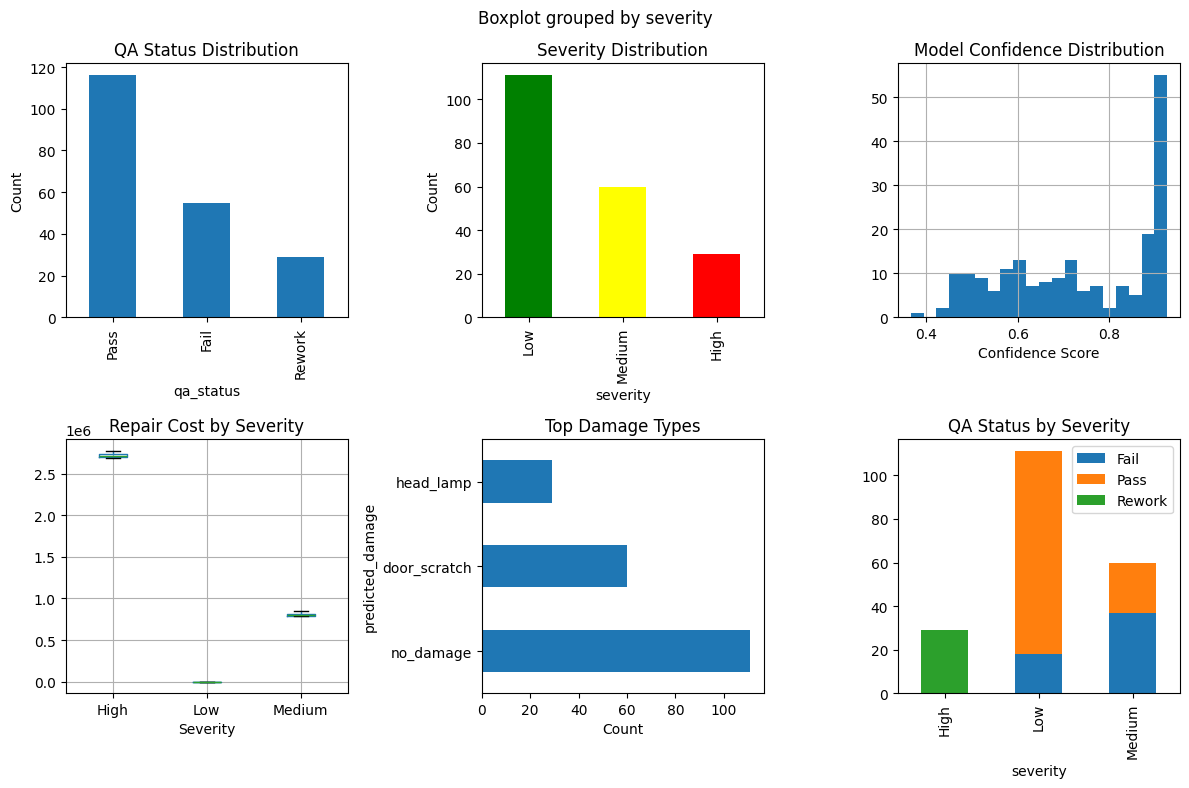

QA insights dashboard saved as 'qa_insights_summary.png'


In [ ]:
# CELL 15: Visualization Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# QA Status
final_qa_table['qa_status'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('QA Status Distribution')
axes[0,0].set_ylabel('Count')

# Severity Distribution
final_qa_table['severity'].value_counts().plot(kind='bar', ax=axes[0,1], color=['green', 'yellow', 'red'])
axes[0,1].set_title('Severity Distribution')
axes[0,1].set_ylabel('Count')

# Confidence Distribution
final_qa_table['confidence'].hist(bins=20, ax=axes[0,2])
axes[0,2].set_title('Model Confidence Distribution')
axes[0,2].set_xlabel('Confidence Score')

# Repair Cost by Severity
final_qa_table.boxplot(column='repair_cost', by='severity', ax=axes[1,0])
axes[1,0].set_title('Repair Cost by Severity')
axes[1,0].set_xlabel('Severity')

# Damage Types
final_qa_table['predicted_damage'].value_counts().plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top Damage Types')
axes[1,1].set_xlabel('Count')

# QA vs Severity Heatmap
pd.crosstab(final_qa_table['severity'], final_qa_table['qa_status']).plot(kind='bar', stacked=True, ax=axes[1,2])
axes[1,2].set_title('QA Status by Severity')
axes[1,2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("QA insights dashboard saved as 'qa_insights_summary.png'")